# Feature Extraction cho Dự đoán Động đất
**Mục tiêu**: Trích xuất và xây dựng các features phù hợp để dự đoán:
1. Độ lớn động đất (Magnitude Prediction)
2. Thời gian xảy ra động đất theo khu vực và năm (Temporal-Spatial Analysis)

**Features được khai thác**:
- Temporal Features: year, month, day, season, day_of_year
- Spatial Features: latitude, longitude, depth, region
- Historical Features: số lượng động đất trước đó, magnitude trung bình khu vực
- Statistical Features: RMS, Gap, Significance
- Categorical Features: magType, status, network

In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("📊 Bắt đầu trích xuất features từ dữ liệu động đất...")

📊 Bắt đầu trích xuất features từ dữ liệu động đất...


## 1. Đọc và Load dữ liệu từ các file JSON

In [2]:
# Đường dẫn đến folder data (lùi 1 cấp từ thienlh/)
folder_path = '../data/**/*.json'

data_list = []
error_count = 0

print("🔄 Đang đọc dữ liệu từ các file JSON...")

for file_path in glob.glob(folder_path, recursive=True):
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
            
            properties = data.get('properties', {})
            geometry = data.get('geometry', {})
            coords = geometry.get('coordinates', [None, None, None])
            
            # FEATURES CƠ BẢN
            mag = properties.get('mag')
            place = properties.get('place')
            time_ms = properties.get('time')
            
            # Chuyển đổi timestamp
            time = pd.to_datetime(time_ms, unit='ms') if time_ms else None
            
            # Tọa độ
            lon = coords[0] if len(coords) > 0 else None
            lat = coords[1] if len(coords) > 1 else None
            depth = coords[2] if len(coords) > 2 else None
            
            # FEATURES BỔ SUNG
            mag_type = properties.get('magType')
            status = properties.get('status')
            tsunami = properties.get('tsunami')
            sig = properties.get('sig')  # Significance
            rms = properties.get('rms')  # Root Mean Square error
            net = properties.get('net')  # Network
            event_id = data.get('id')
            gap = properties.get('gap')  # Azimuthal gap
            dmin = properties.get('dmin')  # Minimum distance
            nst = properties.get('nst')  # Number of stations
            event_type = properties.get('type')
            
            # Thêm vào danh sách
            data_list.append({
                'EventID': event_id,
                'Time': time,
                'Magnitude': mag,
                'Place': place,
                'Longitude': lon,
                'Latitude': lat,
                'Depth': depth,
                'Type': event_type,
                'MagType': mag_type,
                'Status': status,
                'Tsunami': tsunami,
                'Significance': sig,
                'RMS': rms,
                'Network': net,
                'Gap': gap,
                'Dmin': dmin,
                'Nst': nst
            })
            
        except Exception as e:
            error_count += 1
            if error_count <= 5:  # Chỉ hiện 5 lỗi đầu tiên
                print(f"⚠️  Lỗi đọc file {file_path}: {e}")

# Tạo DataFrame
df_raw = pd.DataFrame(data_list)

print(f"✅ Đã đọc xong!")
print(f"📈 Tổng số sự kiện: {len(df_raw)}")
print(f"❌ Số file lỗi: {error_count}")
print(f"\n📋 Các cột dữ liệu thô:")
print(df_raw.columns.tolist())

🔄 Đang đọc dữ liệu từ các file JSON...
✅ Đã đọc xong!
📈 Tổng số sự kiện: 1598809
❌ Số file lỗi: 0

📋 Các cột dữ liệu thô:
['EventID', 'Time', 'Magnitude', 'Place', 'Longitude', 'Latitude', 'Depth', 'Type', 'MagType', 'Status', 'Tsunami', 'Significance', 'RMS', 'Network', 'Gap', 'Dmin', 'Nst']


## 2. Tiền xử lý dữ liệu cơ bản

In [3]:
# Tạo bản sao để xử lý
df = df_raw.copy()

# Loại bỏ các dòng không có thông tin quan trọng
print("🧹 Làm sạch dữ liệu...")
print(f"Trước khi làm sạch: {len(df)} records")

# Loại bỏ các records thiếu thông tin cốt lõi
df = df.dropna(subset=['Time', 'Magnitude', 'Latitude', 'Longitude'])

print(f"Sau khi làm sạch: {len(df)} records")
print(f"Đã loại bỏ: {len(df_raw) - len(df)} records không hợp lệ\n")

# Sắp xếp theo thời gian
df = df.sort_values('Time').reset_index(drop=True)

# Kiểm tra phân bố Magnitude
print("📊 Thống kê Magnitude:")
print(df['Magnitude'].describe())

🧹 Làm sạch dữ liệu...
Trước khi làm sạch: 1598809 records
Sau khi làm sạch: 1598802 records
Đã loại bỏ: 7 records không hợp lệ

📊 Thống kê Magnitude:
count    1.598802e+06
mean     2.702328e+00
std      1.539826e+00
min     -1.000000e+00
25%      1.400000e+00
50%      2.220000e+00
75%      4.300000e+00
max      9.500000e+00
Name: Magnitude, dtype: float64


## 3. Feature Engineering - Temporal Features
Trích xuất các đặc trưng thời gian để dự đoán thời điểm xảy ra động đất

In [5]:
print("⏰ Trích xuất Temporal Features...")

# Trích xuất các thành phần thời gian
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['Day'] = df['Time'].dt.day
df['DayOfWeek'] = df['Time'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayOfYear'] = df['Time'].dt.dayofyear
df['Hour'] = df['Time'].dt.hour

# Phân loại mùa (Season) - theo bán cầu bắc
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# Phân loại thời gian trong ngày
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['Hour'].apply(get_time_of_day)

# Tính số ngày kể từ 1/1/2000 (để sử dụng trong model)
reference_date = pd.Timestamp('2000-01-01')
df['DaysSince2000'] = (df['Time'] - reference_date).dt.days

print("✅ Đã trích xuất Temporal Features:")
print("   - Year, Month, Day, DayOfWeek, DayOfYear, Hour")
print("   - Season, TimeOfDay, DaysSince2000")

⏰ Trích xuất Temporal Features...
✅ Đã trích xuất Temporal Features:
   - Year, Month, Day, DayOfWeek, DayOfYear, Hour
   - Season, TimeOfDay, DaysSince2000


## 4. Feature Engineering - Spatial Features
Phân vùng địa lý và tính toán các đặc trưng không gian

In [6]:
print("🌍 Trích xuất Spatial Features...")

# Phân loại độ sâu động đất
def classify_depth(depth):
    if pd.isna(depth):
        return 'Unknown'
    elif depth < 70:
        return 'Shallow'
    elif depth < 300:
        return 'Intermediate'
    else:
        return 'Deep'

df['DepthCategory'] = df['Depth'].apply(classify_depth)

# Phân vùng địa lý theo lưới (Grid-based)
# Chia thế giới thành các ô lưới 10x10 độ
df['LatGrid'] = (df['Latitude'] // 10) * 10
df['LonGrid'] = (df['Longitude'] // 10) * 10
df['Region'] = df['LatGrid'].astype(str) + '_' + df['LonGrid'].astype(str)

# Tính khoảng cách từ tâm Trái Đất (để phát hiện động đất sâu bất thường)
EARTH_RADIUS = 6371  # km
df['DistanceFromCenter'] = EARTH_RADIUS - df['Depth'].fillna(0)

# Phân loại theo vùng kiến tạo chính (đơn giản hóa)
def classify_tectonic_region(lat, lon):
    # Ring of Fire (Thái Bình Dương)
    if (-180 <= lon <= -60 or 120 <= lon <= 180) and (-60 <= lat <= 60):
        return 'Pacific_Ring_of_Fire'
    # Mediterranean-Alpine
    elif (0 <= lon <= 60) and (30 <= lat <= 50):
        return 'Mediterranean_Alpine'
    # Mid-Atlantic Ridge
    elif (-45 <= lon <= -10) and (-60 <= lat <= 60):
        return 'Mid_Atlantic_Ridge'
    else:
        return 'Other'

df['TectonicRegion'] = df.apply(lambda row: classify_tectonic_region(row['Latitude'], row['Longitude']), axis=1)

print("✅ Đã trích xuất Spatial Features:")
print("   - DepthCategory, LatGrid, LonGrid, Region")
print("   - DistanceFromCenter, TectonicRegion")

🌍 Trích xuất Spatial Features...
✅ Đã trích xuất Spatial Features:
   - DepthCategory, LatGrid, LonGrid, Region
   - DistanceFromCenter, TectonicRegion


## 5. Feature Engineering - Historical Features
Tính toán lịch sử động đất của khu vực để dự đoán

In [7]:
print("📜 Trích xuất Historical Features (có thể mất vài phút)...")

# Sắp xếp theo thời gian để tính toán historical features
df = df.sort_values('Time').reset_index(drop=True)

# Tính số lượng động đất trong khu vực trong 30 ngày trước
def calculate_historical_features(df_input, time_window_days=30, spatial_window=1.0):
    """
    Tính các features dựa trên lịch sử động đất
    - time_window_days: cửa sổ thời gian (ngày)
    - spatial_window: cửa sổ không gian (độ)
    """
    historical_counts = []
    historical_mag_means = []
    historical_mag_maxs = []
    time_since_last = []
    
    for idx, row in df_input.iterrows():
        if idx % 1000 == 0:
            print(f"   Xử lý {idx}/{len(df_input)} records...")
        
        current_time = row['Time']
        current_lat = row['Latitude']
        current_lon = row['Longitude']
        
        # Lọc các động đất trước đó trong khu vực gần
        mask = (
            (df_input['Time'] < current_time) &
            (df_input['Time'] >= current_time - pd.Timedelta(days=time_window_days)) &
            (df_input['Latitude'].between(current_lat - spatial_window, current_lat + spatial_window)) &
            (df_input['Longitude'].between(current_lon - spatial_window, current_lon + spatial_window))
        )
        
        historical_events = df_input[mask]
        
        # Tính các features
        count = len(historical_events)
        mag_mean = historical_events['Magnitude'].mean() if count > 0 else 0
        mag_max = historical_events['Magnitude'].max() if count > 0 else 0
        
        # Thời gian kể từ động đất gần nhất trong khu vực
        if count > 0:
            last_event_time = historical_events['Time'].max()
            days_since = (current_time - last_event_time).days
        else:
            days_since = 9999  # Không có động đất trước đó
        
        historical_counts.append(count)
        historical_mag_means.append(mag_mean)
        historical_mag_maxs.append(mag_max)
        time_since_last.append(days_since)
    
    return historical_counts, historical_mag_means, historical_mag_maxs, time_since_last

# Tính historical features (30 ngày, trong phạm vi 1 độ)
hist_counts, hist_mag_means, hist_mag_maxs, days_since = calculate_historical_features(df, time_window_days=30, spatial_window=1.0)

df['HistoricalCount_30d'] = hist_counts
df['HistoricalMagMean_30d'] = hist_mag_means
df['HistoricalMagMax_30d'] = hist_mag_maxs
df['DaysSinceLastEarthquake'] = days_since

print("✅ Đã trích xuất Historical Features:")
print("   - HistoricalCount_30d: Số động đất trong 30 ngày trước")
print("   - HistoricalMagMean_30d: Magnitude TB khu vực 30 ngày trước")
print("   - HistoricalMagMax_30d: Magnitude MAX khu vực 30 ngày trước")
print("   - DaysSinceLastEarthquake: Số ngày kể từ động đất gần nhất")

📜 Trích xuất Historical Features (có thể mất vài phút)...
   Xử lý 0/1598802 records...
   Xử lý 1000/1598802 records...
   Xử lý 2000/1598802 records...
   Xử lý 3000/1598802 records...
   Xử lý 4000/1598802 records...
   Xử lý 5000/1598802 records...
   Xử lý 6000/1598802 records...
   Xử lý 7000/1598802 records...
   Xử lý 8000/1598802 records...
   Xử lý 9000/1598802 records...
   Xử lý 10000/1598802 records...
   Xử lý 11000/1598802 records...
   Xử lý 12000/1598802 records...
   Xử lý 13000/1598802 records...
   Xử lý 14000/1598802 records...
   Xử lý 15000/1598802 records...
   Xử lý 16000/1598802 records...
   Xử lý 17000/1598802 records...
   Xử lý 18000/1598802 records...
   Xử lý 19000/1598802 records...
   Xử lý 20000/1598802 records...
   Xử lý 21000/1598802 records...
   Xử lý 22000/1598802 records...
   Xử lý 23000/1598802 records...
   Xử lý 24000/1598802 records...
   Xử lý 25000/1598802 records...
   Xử lý 26000/1598802 records...
   Xử lý 27000/1598802 records...
   

## 6. Feature Engineering - Statistical Features
Các features thống kê từ dữ liệu thô

In [8]:
print("📊 Xử lý Statistical Features...")

# Phân loại Magnitude
def classify_magnitude(mag):
    if pd.isna(mag):
        return 'Unknown'
    elif mag < 5.5:
        return 'Moderate'  # 5.0-5.4
    elif mag < 6.0:
        return 'Strong'    # 5.5-5.9
    elif mag < 7.0:
        return 'Major'     # 6.0-6.9
    else:
        return 'Great'     # 7.0+

df['MagnitudeCategory'] = df['Magnitude'].apply(classify_magnitude)

# Điền giá trị thiếu cho các cột số
df['RMS'] = df['RMS'].fillna(df['RMS'].median())
df['Gap'] = df['Gap'].fillna(df['Gap'].median())
df['Dmin'] = df['Dmin'].fillna(df['Dmin'].median())
df['Nst'] = df['Nst'].fillna(df['Nst'].median())
df['Significance'] = df['Significance'].fillna(df['Significance'].median())
df['Depth'] = df['Depth'].fillna(df['Depth'].median())

# Tạo flag cho Tsunami
df['HasTsunami'] = df['Tsunami'].apply(lambda x: 1 if x == 1 else 0)

# Độ tin cậy dữ liệu (dựa trên số station và gap)
df['DataQuality'] = 'Low'
df.loc[(df['Nst'] >= 10) & (df['Gap'] <= 180), 'DataQuality'] = 'Medium'
df.loc[(df['Nst'] >= 20) & (df['Gap'] <= 90), 'DataQuality'] = 'High'

print("✅ Đã xử lý Statistical Features:")
print("   - MagnitudeCategory, HasTsunami, DataQuality")
print("   - Đã điền giá trị thiếu cho RMS, Gap, Dmin, Nst, Significance")

📊 Xử lý Statistical Features...
✅ Đã xử lý Statistical Features:
   - MagnitudeCategory, HasTsunami, DataQuality
   - Đã điền giá trị thiếu cho RMS, Gap, Dmin, Nst, Significance


## 7. Feature Engineering - Tính năng bổ sung cho Prediction

In [9]:
print("🎯 Tạo Target Variables và Features cuối cùng...")

# Tính trung bình magnitude theo khu vực (để dự đoán)
region_mag_stats = df.groupby('Region')['Magnitude'].agg(['mean', 'std', 'count']).reset_index()
region_mag_stats.columns = ['Region', 'RegionMagMean', 'RegionMagStd', 'RegionEventCount']

df = df.merge(region_mag_stats, on='Region', how='left')

# Tính tần suất động đất theo năm trong khu vực
yearly_region_stats = df.groupby(['Year', 'Region']).size().reset_index(name='YearlyRegionCount')
df = df.merge(yearly_region_stats, on=['Year', 'Region'], how='left')

# Chuẩn hóa tọa độ (để dễ sử dụng trong ML models)
from sklearn.preprocessing import MinMaxScaler

scaler_lon = MinMaxScaler()
scaler_lat = MinMaxScaler()

df['Longitude_Normalized'] = scaler_lon.fit_transform(df[['Longitude']])
df['Latitude_Normalized'] = scaler_lat.fit_transform(df[['Latitude']])

print("✅ Đã tạo các features bổ sung:")
print("   - RegionMagMean, RegionMagStd, RegionEventCount")
print("   - YearlyRegionCount")
print("   - Longitude_Normalized, Latitude_Normalized")

🎯 Tạo Target Variables và Features cuối cùng...
✅ Đã tạo các features bổ sung:
   - RegionMagMean, RegionMagStd, RegionEventCount
   - YearlyRegionCount
   - Longitude_Normalized, Latitude_Normalized


## 8. Tổng hợp và Xuất dữ liệu

In [10]:
print("\n" + "="*60)
print("📊 TỔNG HỢP FEATURES ĐÃ TRÍCH XUẤT")
print("="*60)

# Liệt kê tất cả các features
print(f"\n✅ Tổng số features: {len(df.columns)}")
print(f"✅ Tổng số records: {len(df)}")

print("\n📋 Danh sách tất cả các features:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n" + "="*60)
print("📈 THỐNG KÊ DỮ LIỆU")
print("="*60)

print("\n🔢 Features số (Numerical):")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Có {len(numerical_cols)} features số")

print("\n📝 Features phân loại (Categorical):")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Có {len(categorical_cols)} features phân loại")

print("\n⏰ Phạm vi thời gian dữ liệu:")
print(f"   Từ: {df['Time'].min()}")
print(f"   Đến: {df['Time'].max()}")
print(f"   Số năm: {df['Year'].nunique()} năm")

print("\n🌍 Phân bố không gian:")
print(f"   Số vùng (Regions): {df['Region'].nunique()}")
print(f"   Số vùng kiến tạo: {df['TectonicRegion'].nunique()}")

print("\n📊 Phân bố Magnitude:")
print(df['MagnitudeCategory'].value_counts())

# Hiển thị mẫu dữ liệu
print("\n" + "="*60)
print("👀 XEM MẪU DỮ LIỆU (5 RECORDS ĐẦU TIÊN)")
print("="*60)
df.head()


📊 TỔNG HỢP FEATURES ĐÃ TRÍCH XUẤT

✅ Tổng số features: 45
✅ Tổng số records: 1598802

📋 Danh sách tất cả các features:
    1. EventID
    2. Time
    3. Magnitude
    4. Place
    5. Longitude
    6. Latitude
    7. Depth
    8. Type
    9. MagType
   10. Status
   11. Tsunami
   12. Significance
   13. RMS
   14. Network
   15. Gap
   16. Dmin
   17. Nst
   18. Year
   19. Month
   20. Day
   21. DayOfWeek
   22. DayOfYear
   23. Hour
   24. Season
   25. TimeOfDay
   26. DaysSince2000
   27. DepthCategory
   28. LatGrid
   29. LonGrid
   30. Region
   31. DistanceFromCenter
   32. TectonicRegion
   33. HistoricalCount_30d
   34. HistoricalMagMean_30d
   35. HistoricalMagMax_30d
   36. DaysSinceLastEarthquake
   37. MagnitudeCategory
   38. HasTsunami
   39. DataQuality
   40. RegionMagMean
   41. RegionMagStd
   42. RegionEventCount
   43. YearlyRegionCount
   44. Longitude_Normalized
   45. Latitude_Normalized

📈 THỐNG KÊ DỮ LIỆU

🔢 Features số (Numerical):
   Có 31 features số

📝 

,EventID,Time,Magnitude,Place,Longitude,Latitude,Depth,Type,MagType,Status,...,DaysSinceLastEarthquake,MagnitudeCategory,HasTsunami,DataQuality,RegionMagMean,RegionMagStd,RegionEventCount,YearlyRegionCount,Longitude_Normalized,Latitude_Normalized
0,cent19000105190000000,1900-01-05 19:00:00,7.0,"Southern Sumatra, Indonesia",102.00,-3.00,9.163,earthquake,ms,reviewed,...,9999,Great,0,Medium,4.711328,0.498493,7282,1,0.783333,0.473913
1,cent19000111090700000,1900-01-11 09:07:00,7.0,Bismarck Sea,148.00,-5.00,9.163,earthquake,ms,reviewed,...,9999,Great,0,Medium,4.578505,0.582863,13347,2,0.911111,0.462272
2,cent19000120063300000,1900-01-20 06:33:00,7.3,"Jalisco, Mexico",-105.00,20.00,9.163,earthquake,mw,reviewed,...,9999,Great,0,Medium,4.619877,0.687076,816,1,0.208333,0.607783
3,cent19000131192200000,1900-01-31 19:22:00,7.5,Sea of Okhotsk,146.00,48.00,450.000,earthquake,mj,reviewed,...,9999,Great,0,Medium,4.675937,0.581363,12487,3,0.905555,0.770756
4,ushis388,1900-04-09 14:00:00,3.4,"Near Berea, Ohio",-81.85,41.37,0.000,quarry blast,mfa,automatic,...,9999,Moderate,0,Medium,3.605075,0.712463,67,1,0.272638,0.732166


## 9. Lưu dữ liệu đã xử lý

In [11]:
# Lưu dữ liệu đã extract features
output_file = 'earthquake_features_extracted.csv'

print(f"💾 Đang lưu dữ liệu vào file {output_file}...")

# Chọn các cột quan trọng để lưu (loại bỏ một số cột không cần thiết)
columns_to_save = [
    # Identifiers
    'EventID', 'Time',
    
    # Target Variables
    'Magnitude', 'MagnitudeCategory',
    
    # Spatial Features
    'Latitude', 'Longitude', 'Latitude_Normalized', 'Longitude_Normalized',
    'Depth', 'DepthCategory', 'Region', 'TectonicRegion',
    'LatGrid', 'LonGrid',
    
    # Temporal Features
    'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'Hour',
    'Season', 'TimeOfDay', 'DaysSince2000',
    
    # Historical Features
    'HistoricalCount_30d', 'HistoricalMagMean_30d', 'HistoricalMagMax_30d',
    'DaysSinceLastEarthquake',
    
    # Statistical Features
    'RMS', 'Gap', 'Dmin', 'Nst', 'Significance',
    'MagType', 'Status', 'Network', 'HasTsunami', 'DataQuality',
    
    # Regional Features
    'RegionMagMean', 'RegionMagStd', 'RegionEventCount',
    'YearlyRegionCount',
    
    # Original Info
    'Place', 'Type'
]

df_to_save = df[columns_to_save].copy()

# Lưu file
df_to_save.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Đã lưu thành công!")
print(f"📂 File: {output_file}")
print(f"📊 Số dòng: {len(df_to_save)}")
print(f"📋 Số cột: {len(df_to_save.columns)}")

print("\n" + "="*60)
print("🎉 HOÀN THÀNH TRÍCH XUẤT FEATURES!")
print("="*60)
print("\n💡 Bước tiếp theo:")
print("   1. Sử dụng file CSV này để train models dự đoán Magnitude")
print("   2. Phân tích temporal-spatial patterns")
print("   3. Xây dựng hệ thống cảnh báo sớm động đất")

💾 Đang lưu dữ liệu vào file earthquake_features_extracted.csv...
✅ Đã lưu thành công!
📂 File: earthquake_features_extracted.csv
📊 Số dòng: 1598802
📋 Số cột: 43

🎉 HOÀN THÀNH TRÍCH XUẤT FEATURES!

💡 Bước tiếp theo:
   1. Sử dụng file CSV này để train models dự đoán Magnitude
   2. Phân tích temporal-spatial patterns
   3. Xây dựng hệ thống cảnh báo sớm động đất


## 10. Phân tích Features quan trọng

📊 Phân tích các Features quan trọng...


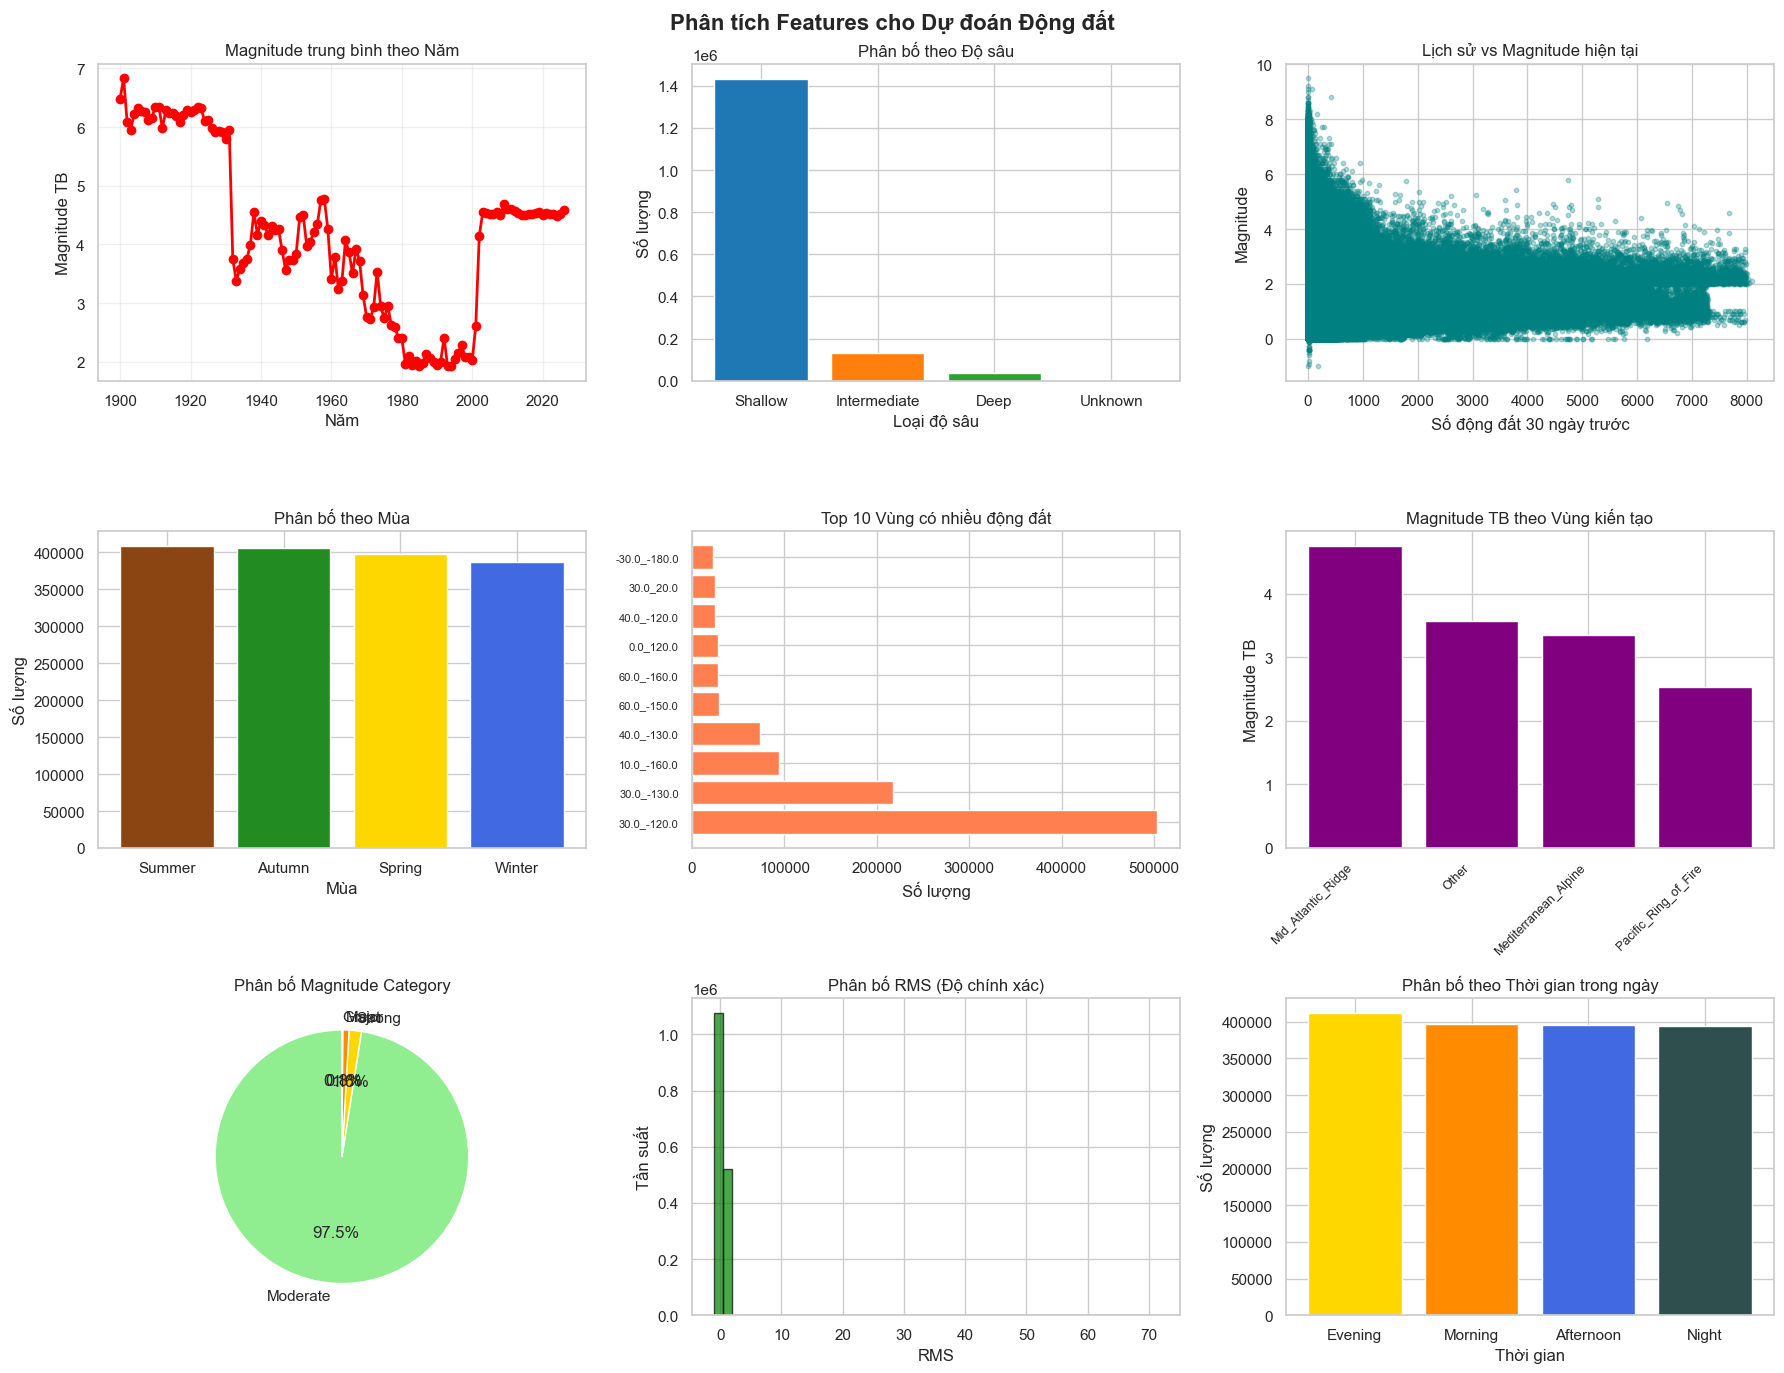

✅ Đã lưu biểu đồ phân tích vào file 'features_analysis.png'


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

print("📊 Phân tích các Features quan trọng...")

# Tạo figure với nhiều subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Phân tích Features cho Dự đoán Động đất', fontsize=16, fontweight='bold')

# 1. Phân bố Magnitude theo năm
ax1 = axes[0, 0]
yearly_mag = df.groupby('Year')['Magnitude'].mean()
ax1.plot(yearly_mag.index, yearly_mag.values, marker='o', linewidth=2, color='red')
ax1.set_title('Magnitude trung bình theo Năm')
ax1.set_xlabel('Năm')
ax1.set_ylabel('Magnitude TB')
ax1.grid(True, alpha=0.3)

# 2. Phân bố theo Depth Category
ax2 = axes[0, 1]
depth_counts = df['DepthCategory'].value_counts()
ax2.bar(depth_counts.index, depth_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax2.set_title('Phân bố theo Độ sâu')
ax2.set_xlabel('Loại độ sâu')
ax2.set_ylabel('Số lượng')

# 3. Correlation giữa Historical Count và Magnitude
ax3 = axes[0, 2]
ax3.scatter(df['HistoricalCount_30d'], df['Magnitude'], alpha=0.3, s=10, color='teal')
ax3.set_title('Lịch sử vs Magnitude hiện tại')
ax3.set_xlabel('Số động đất 30 ngày trước')
ax3.set_ylabel('Magnitude')

# 4. Phân bố theo Season
ax4 = axes[1, 0]
season_counts = df['Season'].value_counts()
ax4.bar(season_counts.index, season_counts.values, color=['#8B4513', '#228B22', '#FFD700', '#4169E1'])
ax4.set_title('Phân bố theo Mùa')
ax4.set_xlabel('Mùa')
ax4.set_ylabel('Số lượng')

# 5. Top 10 Regions có nhiều động đất nhất
ax5 = axes[1, 1]
top_regions = df['Region'].value_counts().head(10)
ax5.barh(range(len(top_regions)), top_regions.values, color='coral')
ax5.set_yticks(range(len(top_regions)))
ax5.set_yticklabels(top_regions.index, fontsize=8)
ax5.set_title('Top 10 Vùng có nhiều động đất')
ax5.set_xlabel('Số lượng')

# 6. Magnitude theo Tectonic Region
ax6 = axes[1, 2]
tectonic_mag = df.groupby('TectonicRegion')['Magnitude'].mean().sort_values(ascending=False)
ax6.bar(range(len(tectonic_mag)), tectonic_mag.values, color='purple')
ax6.set_xticks(range(len(tectonic_mag)))
ax6.set_xticklabels(tectonic_mag.index, rotation=45, ha='right', fontsize=9)
ax6.set_title('Magnitude TB theo Vùng kiến tạo')
ax6.set_ylabel('Magnitude TB')

# 7. Phân bố Magnitude Category
ax7 = axes[2, 0]
mag_cat_counts = df['MagnitudeCategory'].value_counts()
colors_mag = ['#90EE90', '#FFD700', '#FF8C00', '#DC143C']
ax7.pie(mag_cat_counts.values, labels=mag_cat_counts.index, autopct='%1.1f%%', colors=colors_mag, startangle=90)
ax7.set_title('Phân bố Magnitude Category')

# 8. RMS Distribution (Độ chính xác)
ax8 = axes[2, 1]
ax8.hist(df['RMS'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
ax8.set_title('Phân bố RMS (Độ chính xác)')
ax8.set_xlabel('RMS')
ax8.set_ylabel('Tần suất')

# 9. Time of Day Distribution
ax9 = axes[2, 2]
time_counts = df['TimeOfDay'].value_counts()
ax9.bar(time_counts.index, time_counts.values, color=['#FFD700', '#FF8C00', '#4169E1', '#2F4F4F'])
ax9.set_title('Phân bố theo Thời gian trong ngày')
ax9.set_xlabel('Thời gian')
ax9.set_ylabel('Số lượng')

plt.tight_layout()
plt.savefig('features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ phân tích vào file 'features_analysis.png'")

## 11. Correlation Matrix cho các Features số

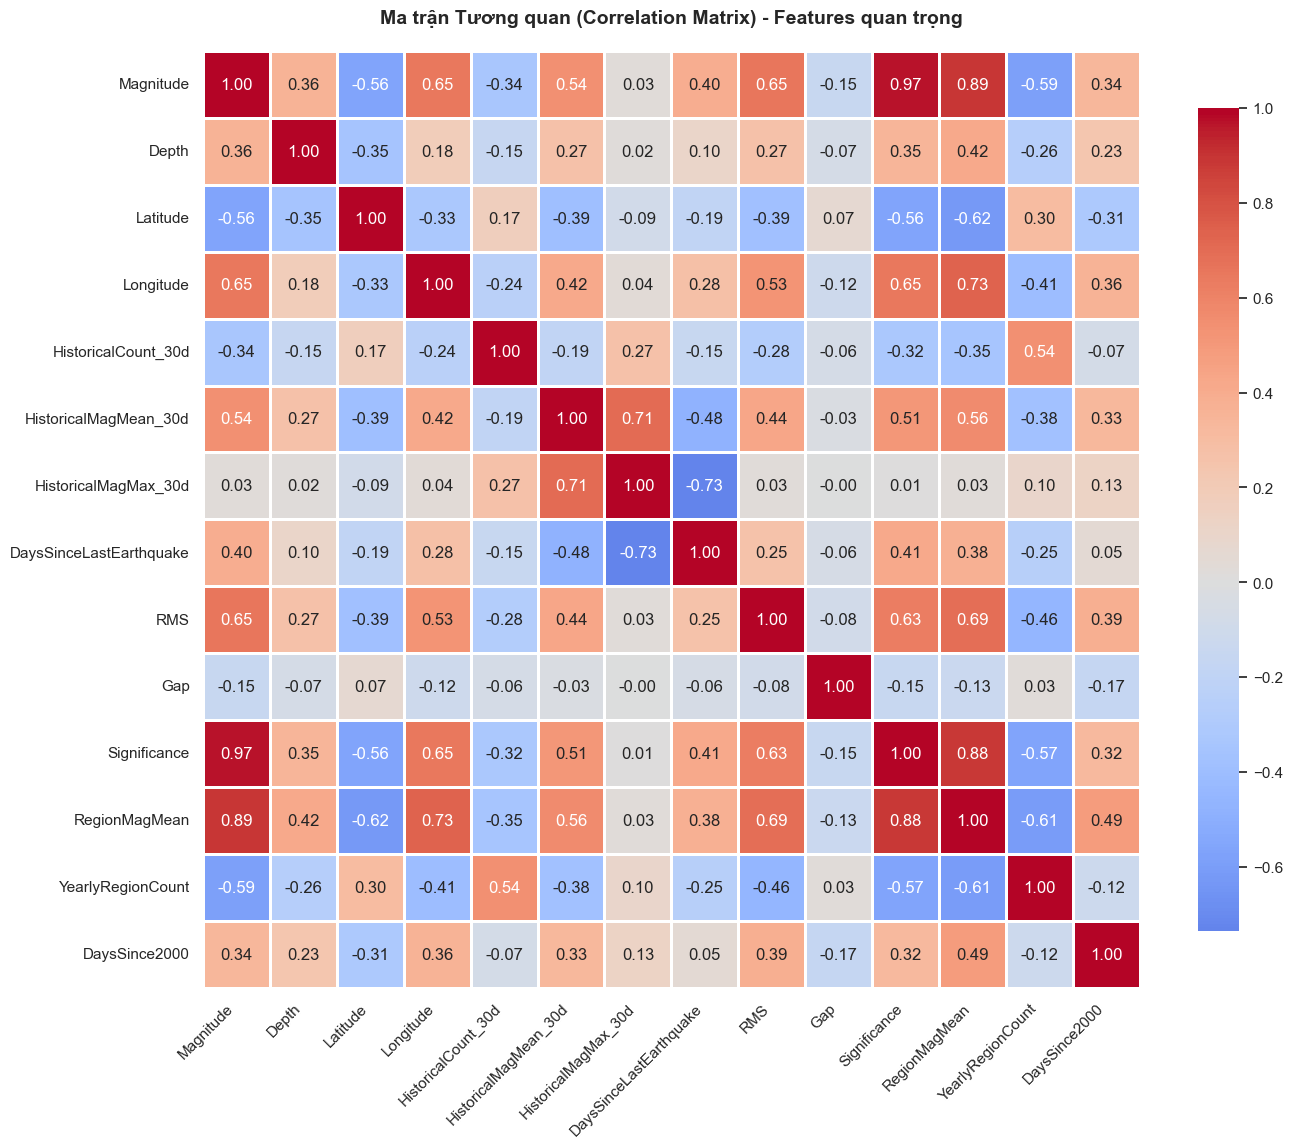

✅ Đã lưu ma trận tương quan vào file 'correlation_matrix.png'

🔍 Top Correlations với Magnitude:
Magnitude                  1.000000
Significance               0.970657
RegionMagMean              0.889641
RMS                        0.654458
Longitude                  0.651867
HistoricalMagMean_30d      0.543652
DaysSinceLastEarthquake    0.395735
Depth                      0.360017
DaysSince2000              0.338596
HistoricalMagMax_30d       0.026853
Gap                       -0.146963
HistoricalCount_30d       -0.340108
Latitude                  -0.558719
YearlyRegionCount         -0.591487
Name: Magnitude, dtype: float64


In [13]:
# Tính correlation matrix cho các features quan trọng
important_numerical_features = [
    'Magnitude', 'Depth', 'Latitude', 'Longitude',
    'HistoricalCount_30d', 'HistoricalMagMean_30d', 'HistoricalMagMax_30d',
    'DaysSinceLastEarthquake', 'RMS', 'Gap', 'Significance',
    'RegionMagMean', 'YearlyRegionCount', 'DaysSince2000'
]

# Lọc các cột tồn tại trong DataFrame
available_features = [col for col in important_numerical_features if col in df.columns]

# Tính correlation
corr_matrix = df[available_features].corr()

# Vẽ heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Ma trận Tương quan (Correlation Matrix) - Features quan trọng', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Đã lưu ma trận tương quan vào file 'correlation_matrix.png'")

print("\n🔍 Top Correlations với Magnitude:")
mag_corr = corr_matrix['Magnitude'].sort_values(ascending=False)
print(mag_corr)

## 12. Summary Report - Báo cáo tổng kết

In [14]:
print("\n" + "="*80)
print(" "*20 + "BÁO CÁO FEATURES EXTRACTION")
print("="*80)

print(f"\n📊 TỔNG QUAN DỮ LIỆU:")
print(f"   ├─ Tổng số sự kiện động đất: {len(df):,}")
print(f"   ├─ Phạm vi thời gian: {df['Year'].min()} - {df['Year'].max()}")
print(f"   ├─ Số vùng (Region): {df['Region'].nunique():,}")
print(f"   └─ Số năm: {df['Year'].nunique()} năm")

print(f"\n🎯 FEATURES CHO DỰ ĐOÁN:")
print(f"   ├─ Tổng số features: {len(columns_to_save)}")
print(f"   ├─ Temporal features: 9 (Year, Month, Season, etc.)")
print(f"   ├─ Spatial features: 9 (Lat, Lon, Depth, Region, etc.)")
print(f"   ├─ Historical features: 4 (30-day history)")
print(f"   ├─ Statistical features: 10 (RMS, Gap, Significance, etc.)")
print(f"   └─ Regional features: 3 (Region stats)")

print(f"\n📈 PHÂN BỐ MAGNITUDE:")
for cat, count in df['MagnitudeCategory'].value_counts().items():
    pct = (count / len(df)) * 100
    print(f"   ├─ {cat}: {count:,} ({pct:.1f}%)")

print(f"\n🌍 TOP 5 VÙNG CÓ NHIỀU ĐỘNG ĐẤT NHẤT:")
for i, (region, count) in enumerate(df['Region'].value_counts().head(5).items(), 1):
    print(f"   {i}. {region}: {count:,} events")

print(f"\n🔥 TOP 5 VÙNG CÓ MAGNITUDE CAO NHẤT:")
top_mag_regions = df.groupby('Region')['Magnitude'].mean().sort_values(ascending=False).head(5)
for i, (region, mag) in enumerate(top_mag_regions.items(), 1):
    print(f"   {i}. {region}: {mag:.2f}")

print(f"\n⚡ THỐNG KÊ LỊCH SỬ ĐỘNG ĐẤT:")
print(f"   ├─ TB số động đất trong 30 ngày: {df['HistoricalCount_30d'].mean():.1f}")
print(f"   ├─ Max số động đất trong 30 ngày: {df['HistoricalCount_30d'].max()}")
print(f"   └─ TB khoảng cách thời gian giữa các trận: {df['DaysSinceLastEarthquake'].median():.0f} ngày")

print(f"\n💾 OUTPUT FILES:")
print(f"   ├─ {output_file} (Dữ liệu đã xử lý)")
print(f"   ├─ features_analysis.png (Biểu đồ phân tích)")
print(f"   └─ correlation_matrix.png (Ma trận tương quan)")

print("\n" + "="*80)
print(" "*25 + "🎉 HOÀN THÀNH! 🎉")
print("="*80)

print("\n💡 GỢI Ý SỬ DỤNG:")
print("   1. Sử dụng Historical Features để dự đoán Magnitude động đất")
print("   2. Sử dụng Temporal + Spatial Features để dự đoán thời gian & vị trí")
print("   3. Phân tích Regional Features để xác định vùng nguy hiểm")
print("   4. Kết hợp tất cả features để xây dựng Early Warning System")

print("\n📚 MODELS ĐỀ XUẤT:")
print("   ├─ Random Forest / XGBoost: Dự đoán Magnitude")
print("   ├─ LSTM / GRU: Dự đoán Time Series")
print("   ├─ CNN: Phân tích Spatial Patterns")
print("   └─ Hybrid Model: Kết hợp tất cả")


                    BÁO CÁO FEATURES EXTRACTION

📊 TỔNG QUAN DỮ LIỆU:
   ├─ Tổng số sự kiện động đất: 1,598,802
   ├─ Phạm vi thời gian: 1900 - 2026
   ├─ Số vùng (Region): 531
   └─ Số năm: 127 năm

🎯 FEATURES CHO DỰ ĐOÁN:
   ├─ Tổng số features: 43
   ├─ Temporal features: 9 (Year, Month, Season, etc.)
   ├─ Spatial features: 9 (Lat, Lon, Depth, Region, etc.)
   ├─ Historical features: 4 (30-day history)
   ├─ Statistical features: 10 (RMS, Gap, Significance, etc.)
   └─ Regional features: 3 (Region stats)

📈 PHÂN BỐ MAGNITUDE:
   ├─ Moderate: 1,559,400 (97.5%)
   ├─ Strong: 25,045 (1.6%)
   ├─ Major: 12,778 (0.8%)
   ├─ Great: 1,579 (0.1%)

🌍 TOP 5 VÙNG CÓ NHIỀU ĐỘNG ĐẤT NHẤT:
   1. 30.0_-120.0: 502,828 events
   2. 30.0_-130.0: 217,191 events
   3. 10.0_-160.0: 94,212 events
   4. 40.0_-130.0: 74,037 events
   5. 60.0_-150.0: 29,166 events

🔥 TOP 5 VÙNG CÓ MAGNITUDE CAO NHẤT:
   1. -60.0_-110.0: 6.35
   2. -70.0_-120.0: 5.75
   3. -30.0_100.0: 5.73
   4. -40.0_10.0: 5.73
   5. -60